In [43]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

# STEP A — PCA on socioeconomic variables (tract-level)

Procedure:

    • Standardize variables
    • Run PCA
    • Keep PC1–PC3 (likely ≥60–80% variance)
    • Extract tract-level PCA scores

Figures:

    • Scree plot
    • Loading plot (which variables drive each PC)
    • Table of PCA scores by tract

In [44]:
#pulling standardized socioeconomic variables
tract_socioeconomic = pd.read_csv('data_processed/PCA_data/tract_socioeconomic.csv')
tract_socioeconomic['TRACT'] = tract_socioeconomic['TRACT'].astype(str).str.zfill(6)

In [45]:
# show missing counts per column
print(tract_socioeconomic.isna().sum().sort_values(ascending=False).head(20))

# fraction missing per column
print((tract_socioeconomic.isna().mean()).sort_values(ascending=False).head(20))

# how many rows have any missing
print("Rows with any NaN:", tract_socioeconomic.isna().any(axis=1).sum(), " / ", len(tract_socioeconomic))

# optionally inspect rows with missing
missing_rows = tract_socioeconomic[tract_socioeconomic.isna().any(axis=1)]
missing_rows.head()


median_household_income                     48
american_indian_alaska_native                0
pct_over65                                   0
pct_with_disability                          0
population_below_50pct_poverty               0
population_civilian_noninstitutionalized     0
population_over65                            0
population_with_disability                   0
rent_30_to_34_pct_income                     0
rent_35_to_39_pct_income                     0
rent_40_to_49_pct_income                     0
rent_50_plus_pct_income                      0
renter_occupied_housing_units                0
some_other_race                              0
total_households_in_internet_table           0
total_households_vehicle_data                0
total_housing_units                          0
total_population                             0
total_renters                                0
two_or_more_races                            0
dtype: int64
median_household_income                     0.0

,american_indian_alaska_native,asian_alone,bachelors_degree,black_alone,female_65_66,female_67_69,female_70_74,female_75_79,female_80_84,female_85_plus,...,renter_occupied_housing_units,some_other_race,total_households_in_internet_table,total_households_vehicle_data,total_housing_units,total_population,total_renters,two_or_more_races,white_alone,TRACT
50,-0.169677,-0.412668,-1.237962,-0.713423,-1.122729,-0.953614,-0.964382,-1.204844,-1.060743,-0.457997,...,-1.138209,-0.667024,-2.002619,-2.002619,-2.002619,-1.893817,-1.138209,-0.914575,-1.485004,920302
55,-0.142175,-0.375424,-1.233484,-0.179932,-1.122729,-0.764597,-1.296124,-1.150463,-1.060743,-0.843800,...,-1.267610,-0.586770,-2.344428,-2.344428,-2.344428,-1.280129,-1.267610,-0.796686,-1.116347,980000
142,-0.188011,-0.412668,-1.284979,-0.925466,-1.122729,-1.256040,-1.337591,-1.204844,-1.060743,-0.843800,...,-1.267610,-0.667024,-2.344428,-2.344428,-2.344428,-2.234882,-1.267610,-1.001900,-1.750493,990100
202,-0.073420,-0.399125,-0.167770,-0.861176,-0.540299,-0.651187,-0.397657,2.184873,0.693159,9.425907,...,0.197304,-0.667024,-0.775768,-0.775768,-0.775768,-1.001232,0.197304,-0.884011,-0.340514,003108
327,-0.188011,-0.412668,-1.284979,-0.925466,-1.122729,-1.256040,-1.337591,-1.204844,-1.060743,-0.843800,...,-1.267610,-0.667024,-2.344428,-2.344428,-2.344428,-2.234882,-1.267610,-1.001900,-1.750493,980100


In [46]:
#Dropping the tracts with NAs
tract_socioeconomic_clean = tract_socioeconomic.dropna()

#Keeping derived calculations only
ses_vars = [
    "median_household_income",
    "pct_below_50pct_poverty",
    "pct_no_vehicle",
    "pct_renters_cost_burdened",
    "pct_over65",
    "pct_with_disability",
    "pct_nonwhite"
]

In [47]:
# Separate features and ID
X = tract_socioeconomic_clean.drop(columns=['TRACT'])  
X = X[ses_vars] 
tract_ids = tract_socioeconomic_clean['TRACT']      


## Scree Plot

To see how many PCs to keep

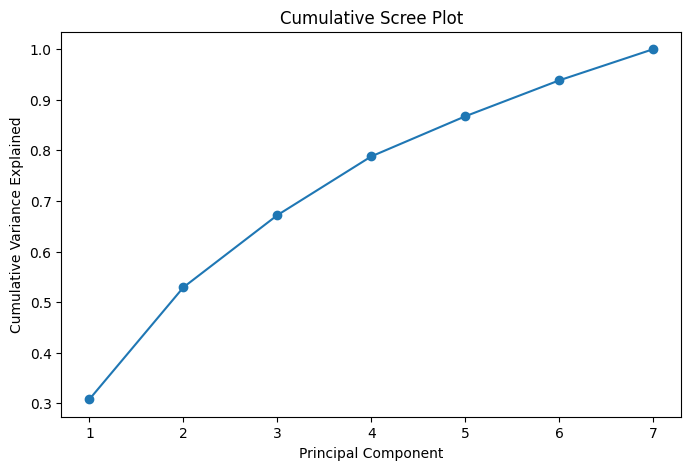

In [51]:
pca = PCA(n_components=7)
pca_scores = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Scree Plot")
plt.show()

PC1: ~32%

PC2: ~18% (cumulative ~50%)

PC3: ~16% (cumulative ~66%)

PC4: ~13% (cumulative ~79%)

PC5: ~10% (cumulative ~89%)

PC6: ~8% (cumulative ~97%)

PC7: the rest

PC 1-3 is probably sufficient

## Running PCA for 3 components

In [49]:
# Keeping first three principle components
pca = PCA(n_components=3)
pca_scores = pca.fit_transform(X)

In [50]:
# Turn PCA scores into a dataframe
socioeconomic_tract_pca_scores = pd.DataFrame(
    pca_scores,
    columns=['PC1', 'PC2', 'PC3']
)
socioeconomic_tract_pca_scores['TRACT'] = tract_ids.values   # add back id

# Get PCA loadings
socioeconomic_tract_loadings = pd.DataFrame(
    pca.components_.T,     # each row = variable, each column = PC
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)



In [25]:
fig = px.scatter_3d(
    socioeconomic_tract_pca_scores,
    x="PC1",
    y="PC2",
    z="PC3",
    hover_name="TRACT",  
    opacity=0.5
)

fig.update_layout(
    title="Interactive 3D PCA Scatterplot of Census Tracts",
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)

fig.show()

PCA transforms correlated socioeconomic variables into a smaller number of independent components PC1, PC2, PC3.

tract_socioeconomic_pca: Displays tract-level PCA scores

PCA Scores: where does each tract lie along these abstract socioeconomic axes

Loadings: which variables define each principal component (ie which pattern does PC1, PC2, and PC3 represent). The are weights linking original variables to each principal component.

## Loadings Interpretation:

### PC1

PC1 is the “structural disadvantage” axis.
High scores = younger, poorer, more racially diverse communities with higher disability rates and more rent burden.
Low scores = older, wealthier, mostly white communities with low poverty.

### PC2

Older low-mobility seniors axis.
High scores = older communities with more people who don’t drive, lower incomes, and somewhat higher poverty. Interestingly, these aren’t disability-heavy tracts, they're just older.
Low scores = younger, higher-income tracts with more disability prevalence?

### PC3

Older suburban stability axis.
High scores = older residents who still have vehicles, low rent burden, moderate disability, and not especially poor.
Low scores = younger, more rent-burdened, less vehicle access — more urban pressure.

# STEP B — Cluster census tracts using PCA scores

Use k-means or hierarchical clustering.

Your advisor wants:

    • Cluster tracts based on PC1, PC2, PC3 scores
    • THEN examine outage metrics within each cluster

Output per cluster:

    • Socioeconomic profile (low-income, old housing, rural, etc.)
    • Average outage frequency
    • Average outage duration
    • Weather exposure metrics
    
This gives us: which types of communities experience which outages?

## Choose k (number of clusters)
Via:
- elbow method
- silhouette score

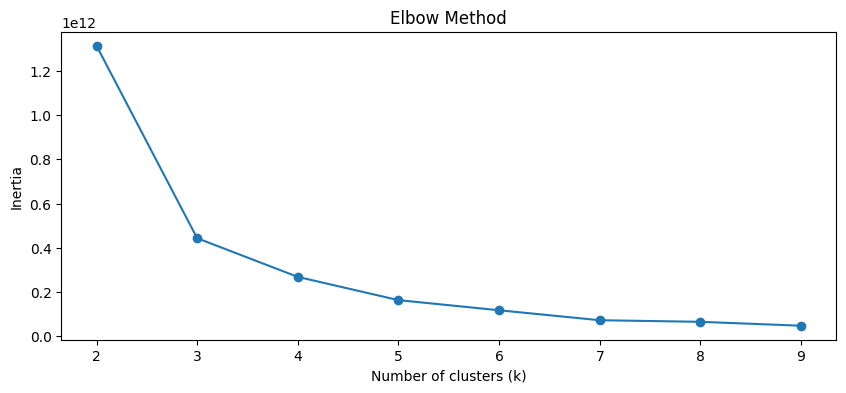

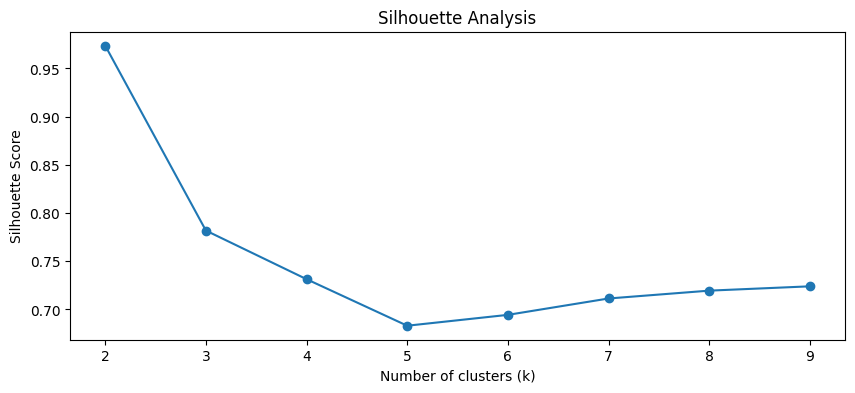

In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = range(2, 10)
inertias = []
silhouettes = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(socioeconomic_tract_pca_scores)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(socioeconomic_tract_pca_scores, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot silhouette
plt.figure(figsize=(10,4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Choosing k = 3

- Where elbow is most visible before diminishing returns begin
- Has a higher silhouette score than k = 4, 5, 6
    - For silhouette score, it's highest at k = 2, but 2 clusters might oversimpliofy the data

## Run clustering (k-means / hierarchical)

In [57]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42)
socioeconomic_tract_pca_scores['cluster'] = kmeans.fit_predict(socioeconomic_tract_pca_scores)

## Characterize each cluster

Using the unscaled, real socioeconomic variables.

In [58]:
#pulling unscaled socioeconomic variables
tract_socioeconomic_unscaled = pd.read_csv('data_processed/PCA_data/tract_socioeconomic_unscaled.csv')
tract_socioeconomic_unscaled['TRACT'] = tract_socioeconomic_unscaled['TRACT'].astype(str).str.zfill(6)

df = tract_socioeconomic_unscaled.merge(socioeconomic_tract_pca_scores[['TRACT','cluster']], on='TRACT')

socioeconomic_cluster_profiles = df.groupby('cluster')[ses_vars].mean()


It does not seem like NC census tracts fall into sharply distinct socioeconomic groups with these socioeconomic variables. So I instead want to identify SES outliers with PCA Distance. These would be socioeconomic "extreme" tracts.

## Identify standout tracts directly using PCA scores and distances

### Identify SES Outliers Using PCA Distance

In [ ]:
pc_df = socioeconomic_tract_pca_scores[['PC1','PC2','PC3']].copy()
pc_df['TRACT'] = socioeconomic_tract_pca_scores['TRACT']

pc_df['distance'] = np.sqrt(pc_df['PC1']**2 + pc_df['PC2']**2 + pc_df['PC3']**2)

#Identifying 20 "outliers"
pc_df.nlargest(20, 'distance')


,PC1,PC2,PC3,TRACT,distance
111,-5.753165,10.203218,8.864188,020307,14.689397
1723,-0.248679,4.557266,7.147838,010801,8.480690
1925,5.181080,3.445750,-3.833075,000101,7.308162
953,3.429725,4.951888,4.127960,011500,7.302346
1964,0.829267,2.140734,5.893037,002004,6.324422
2596,5.766489,1.495202,-0.919431,000801,6.027717
2529,4.114050,2.517282,-3.219593,920601,5.798957
1300,5.630067,0.755928,1.048991,010300,5.776631
125,-3.954972,3.642247,-1.465088,020504,5.572634
2106,-1.033510,2.811771,4.592777,960101,5.483412


### Identify extremes along individual SES axes

In [ ]:
#Finding extremes along individual SES axes
pc_df.sort_values('PC1').head(10)  # most disadvantaged
pc_df.sort_values('PC1').tail(10)  # most advantaged

pc_df.sort_values('PC2')           # seniors with mobility constraints
pc_df.sort_values('PC3')           # older suburban stability vs rent pressure


,PC1,PC2,PC3,TRACT,distance
111,-5.753165,10.203218,8.864188,020307,14.689397
118,-4.127087,1.529074,-0.226080,020316,4.407042
116,-4.055111,0.659413,-0.234450,020314,4.115059
130,-4.032945,3.380780,-0.853562,020512,5.331312
125,-3.954972,3.642247,-1.465088,020504,5.572634
1433,-3.758237,-2.778808,-0.052117,002800,4.674274
1431,-3.717139,-2.268798,-0.203330,002701,4.359576
108,-3.638019,2.312855,-1.552490,020304,4.581998
2452,-3.567617,-0.483432,0.643314,053805,3.657246
2513,-3.474676,2.300692,0.312538,950101,4.179024


### Use hierarchical clustering (Ward’s method)

Hierarchical clustering can reveal:
2 clusters at the top (wealth vs disadvantage), then splits into smaller subgroups, no assumption of spherical boundaries

And the dendrogram helps tell a story.

### Map PCs or SES variables directly

Because clusters are mild, mapping PC1–PC3 across NC may tell a richer story than clustering.

For example:

PC1 map: structural disadvantage gradient

PC2 map: mobility-limited aging populations

PC3 map: older suburban stable areas vs younger cost-burdened areas

## Merge with outage + weather summaries (tract)

I have:
- tract_outages
- tract_weather

Which are summaries of outages and weather for each tract.

This will help compute:
- Outages per cluster
- Durations per cluster
- Weather exposure per cluster

# STEP C — Identify outlier clusters

Define outliers as:

    • Tracts where outage frequency/duration is > 2 standard deviations above cluster mean
    • Tracts with high weather exposure but low outages (or vice versa)